In [213]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo

In [214]:
# Suppress all warnings
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

### Load Cost Data:

In [215]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [216]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

In [217]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

## Load Data

In [218]:
# Get the directory of the current script
current_dir = os.getcwd()

# Build file paths relative to the script location
pv_file = os.path.join(current_dir, "pv_optimal.csv")
wind_file = os.path.join(current_dir, "onshore_wind_1979-2017.csv")
dk1_file = os.path.join(current_dir, "2017_DK1_SpotSprice_Load.xlsx")
# dk1_file = os.path.join(current_dir, "DK1_2017.csv")  # optional alternative

# Read the files
solar_pv_data = pd.read_csv(pv_file, sep=";")
onshore_wind_data = pd.read_csv(wind_file, sep=";")
DK1_data_2017 = pd.read_excel(dk1_file)

In [219]:
solar_pv_data['utc_time'] = pd.to_datetime(solar_pv_data['utc_time']).dt.tz_localize(None)
solar_pv_data.index = pd.DatetimeIndex(solar_pv_data['utc_time'])

onshore_wind_data['utc_time'] = pd.to_datetime(onshore_wind_data['utc_time']).dt.tz_localize(None)
onshore_wind_data.index = pd.DatetimeIndex(onshore_wind_data['utc_time'])

DK1_data_2017["HourUTC"] = pd.to_datetime(DK1_data_2017["HourUTC"], format="%d-%m-%Y %H:%M").dt.tz_localize(None)
DK1_data_2017.index = pd.DatetimeIndex(DK1_data_2017["HourUTC"])

In [220]:
DK1_data_2017.index.max()

Timestamp('2017-12-30 22:00:00')

In [221]:
"Time Period in which our model is running";

hours_in_2017 = pd.date_range('2017-01-01 00:00Z',
                              '2017-12-30 22:00Z',
                              freq='h')

hours_in_2017 = hours_in_2017.tz_localize(None)

print(DK1_data_2017.index.tz)

None


In [222]:
def add_carriers():
    n.add("Carrier", "gas", co2_emissions=0.19) # in t_CO2/MWh_th
    n.add("Carrier", "onshorewind")
    n.add("Carrier", "offshorewind")
    n.add("Carrier", "nuclear")
    n.add("Carrier","solar")
    n.add("Carrier","heat")
    n.add("Carrier","heat pump")
    n.add("Carrier", "electricity")  # Add electricity carrier
    n.add("Carrier", "battery storage")  # Add battery storage carrier
    n.add("Carrier","electric boiler")


In [223]:
def add_skive_generators():

    n.add("Generator", "Skive_Solar", carrier="solar",
        bus ="B1" ,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu=solar_pv_data["DNK"].reindex(hours_in_2017).values, 
        p_nom = 36)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "B1",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu=onshore_wind_data["DNK"].reindex(hours_in_2017).values,
        p_nom = 54)

In [224]:
def add_battery(P_nom, max_t, cyclic_operation = True):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="B1",  # Use your electricity bus name
        carrier="battery storage",
        max_hours= max_t,  # 22 MW * 4 h = 88 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"]
            + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # DIscharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [225]:
def add_TES_rondo(e_nom = 100, p_nom = 24):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        e_nom= e_nom, # MWh
        e_nom_extendable=False,
        e_initial=0,
        e_cyclic=True,
        standing_loss= 1.2/100) # 1.2% per hour

    "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="B1",
        bus1="TES_Rondo",
        p_nom_extendable=False,
        p_nom = p_nom, # MW
        efficiency=0.98,
        carrier = "electricity",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_Bus_Skive",
        p_nom = p_nom,
        p_nom_extendable=False,
        efficiency=0.90,
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [226]:
def  add_heat_load_boiler():
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "B1",
        bus1="Heat_Bus_Skive",
        p_nom = 10, # MW
        efficiency=0.9,
        carrier = "electric boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"])

    n.add("Load", "Skive_Heat_Load", 
        bus="Heat_Bus_Skive",
        p_nom_extendable=False,
        carrier = "heat",
        p_set = 5) # MWh

In [227]:
tariffs = {
    "consumers": {
        "transmission_grid_tariff": 8.2,  # €/MWh
        "reduced_transmission_tariff": 7.5,
        "limited_grid_access_tariff": 3.5,
        "system_tariff": 9.9,
        "system_tariff_above_100GWh": 0.099,
        "system_subscription": 24.4  # €/year
    },
    "producers": {
        "feed_in_tariff": 0.67,  # €/MWh delivered to grid
        "balance_tariff": 0.87
    },
    "BRP": {
        "balancing_fee": 0.13,  # €/MWh imbalance
        "weekly_fee": 30  # €/week
    }
}

# Example of accessing a value
print(tariffs["consumers"]["system_tariff"])  # Output: 9.9


9.9


In [289]:
p_import = tariffs["consumers"]["transmission_grid_tariff"]
p_export = tariffs["producers"]["feed_in_tariff"]

def add_grid(p_import, p_export):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
            bus="Grid_Import",
            p_nom_extendable = True,
            efficiency=1.0,
            marginal_cost=0,
            capital_cost=0.0)
    
    n.add("Link", "Imports",
            bus0="Grid_Import",
            bus1="B1",
            p_nom_extendable=True,
            efficiency=0.97,
            p_max_pu=1.0,
            carrier="electricity",
            marginal_cost=DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).values + p_import)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          efficiency_store=1.0,
          carrier="electricity",
          capital_cost=0.0,
          standing_loss=0.0)

    n.add("Link", "Exports",
            bus0="B1",
            bus1="Grid_Export",
            p_nom = 25,
            p_nom_extendable=False,
            efficiency=0.97,
            p_min_pu=0,
            p_max_pu=1.0,
            carrier="electricity",
            marginal_cost=-DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).values + p_export)

In [277]:
def add_el_load(p_el = 2):
    "Adding the Localised Demand in Greenlab Skive";
    n.add("Load", "Skive_el_Load", 
      bus="B1", 
      p_set= p_el) #MWh


### Simple Model

In [290]:
n = pypsa.Network()

n.set_snapshots(hours_in_2017)

add_carriers()

n.add("Bus", "B1", carrier="electricity")
add_skive_generators()
add_battery(P_nom = 4, max_t = 4, cyclic_operation = True)

add_el_load(p_el = 2)


n.add("Bus", "Heat_Bus_Skive", carrier="heat")
add_heat_load_boiler()

n.add("Bus", "TES_Rondo", carrier="heat")
add_TES_rondo(e_nom = 100, p_nom = 24)


n.add("Bus","Grid_Import", carrier = "electricity")
n.add("Bus","Grid_Export", carrier = "electricity")

add_grid(p_import = p_import ,p_export = p_export)

In [291]:
n.consistency_check()

In [292]:
# Check for missing buses
print("=== Buses ===")
print(n.buses.index.tolist())

print("\n=== Links (bus0 -> bus1) ===")
print(n.links[["bus0", "bus1"]])

print("\n=== Generators (bus) ===")
print(n.generators[["bus"]])

print("\n=== Loads (bus) ===")
print(n.loads[["bus"]])

print("\n=== Storage Units (bus) ===")
print(n.storage_units[["bus"]])

# Check for NaN in time-series
print("\n=== NaN counts in time series ===")
for col in n.generators_t.p_max_pu.columns:
    nan_count = n.generators_t.p_max_pu[col].isna().sum()
    if nan_count > 0:
        print(f"  {col}: {nan_count} NaN values")

print("\n=== Running consistency check ===")
n.consistency_check()

=== Buses ===
['B1', 'Heat_Bus_Skive', 'TES_Rondo', 'Grid_Import', 'Grid_Export']

=== Links (bus0 -> bus1) ===
                                    bus0            bus1
Link                                                    
Boiler_Skive                          B1  Heat_Bus_Skive
El_to_TES_Rondo                       B1       TES_Rondo
TES_Rondo_to_Heat_Bus_Skive    TES_Rondo  Heat_Bus_Skive
Imports                      Grid_Import              B1
Exports                               B1     Grid_Export

=== Generators (bus) ===
                            bus
Generator                      
Skive_Solar                  B1
Skive_Onshore_Wind           B1
Grid_Generator      Grid_Import

=== Loads (bus) ===
                            bus
Load                           
Skive_el_Load                B1
Skive_Heat_Load  Heat_Bus_Skive

=== Storage Units (bus) ===
              bus
StorageUnit      
Skive_Battery  B1

=== NaN counts in time series ===

=== Running consistency check ===


In [ ]:
n.optimize(solver_name="gurobi")

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 20.51it/s]
INFO:linopy.io: Writing time: 3.36s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2602524


INFO:gurobipy:Set parameter LicenseID to value 2602524


...

Barrier performed 14 iterations in 0.96 seconds (0.58 work units)


INFO:gurobipy:Barrier performed 14 iterations in 0.96 seconds (0.58 work units)


Barrier solve interrupted - model solved by another algorithm


INFO:gurobipy:Barrier solve interrupted - model solved by another algorithm


INFO:gurobipy:


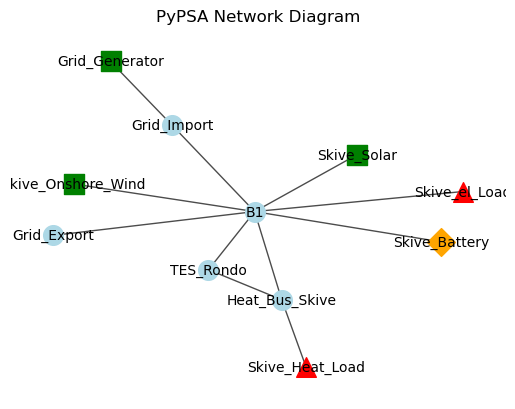

In [262]:
import networkx as nx
import matplotlib.pyplot as plt

# Start with buses and links
G = nx.Graph()

# Add buses
for bus_name in n.buses.index:
    G.add_node(bus_name, type="bus")

# Add links
for link_name, link in n.links.iterrows():
    G.add_edge(link.bus0, link.bus1, type="link", name=link_name)

# Add generators
for gen_name, gen in n.generators.iterrows():
    G.add_node(gen_name, type="generator")
    G.add_edge(gen.bus, gen_name, type="generator_connection")

# Add storage units
for su_name, su in n.storage_units.iterrows():
    G.add_node(su_name, type="storage")
    G.add_edge(su.bus, su_name, type="storage_connection")

# Add loads
for load_name, load in n.loads.iterrows():
    G.add_node(load_name, type="load")
    G.add_edge(load.bus, load_name, type="load_connection")

# Define positions (spring layout or use bus coordinates if available)
pos = nx.spring_layout(G, seed=10)
# Draw edges first
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.7)

# Draw nodes by type with different shapes
node_shapes = {
    "bus": ("o", "lightblue"),          # circle
    "generator": ("s", "green"),        # square
    "storage": ("D", "orange"),         # diamond
    "load": ("^", "red")                # triangle
}

for ntype, (shape, color) in node_shapes.items():
    nodes_of_type = [node for node, attr in G.nodes(data=True) if attr["type"] == ntype]
    nx.draw_networkx_nodes(G, pos,
                           nodelist=nodes_of_type,
                           node_color=color,
                           node_shape=shape,
                           node_size=200,
                           label=ntype.capitalize())

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10)

# Add legend
#plt.legend(scatterpoints=1)
plt.axis("off")
plt.title("PyPSA Network Diagram")
plt.show()

<Axes: xlabel='snapshot'>

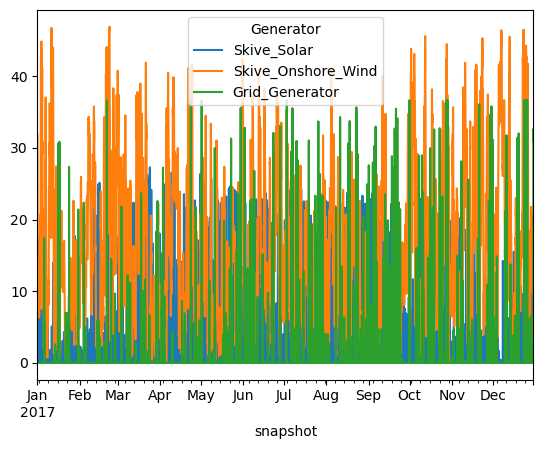

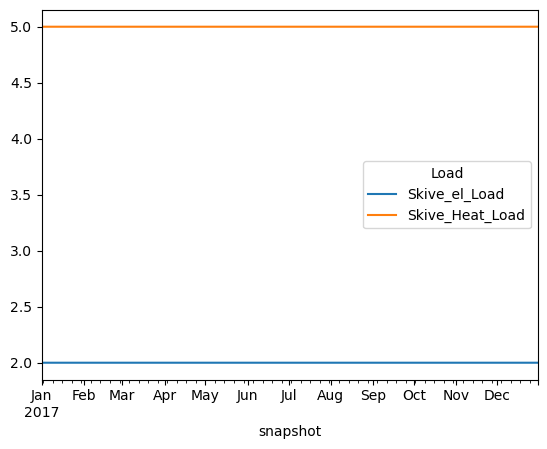

In [282]:
n.generators_t.p.plot()
n.loads_t.p.plot()

In [283]:
# Safe access with fallback
if "Skive_Battery" in n.storage_units_t.p_dispatch.columns:
    n.storage_units_t.p_dispatch["Skive_Battery"].head()
else:
    print("ERROR: 'Skive_Battery' results not found after optimization")
    print("Available storage units:", n.storage_units_t.p_dispatch.columns.tolist())

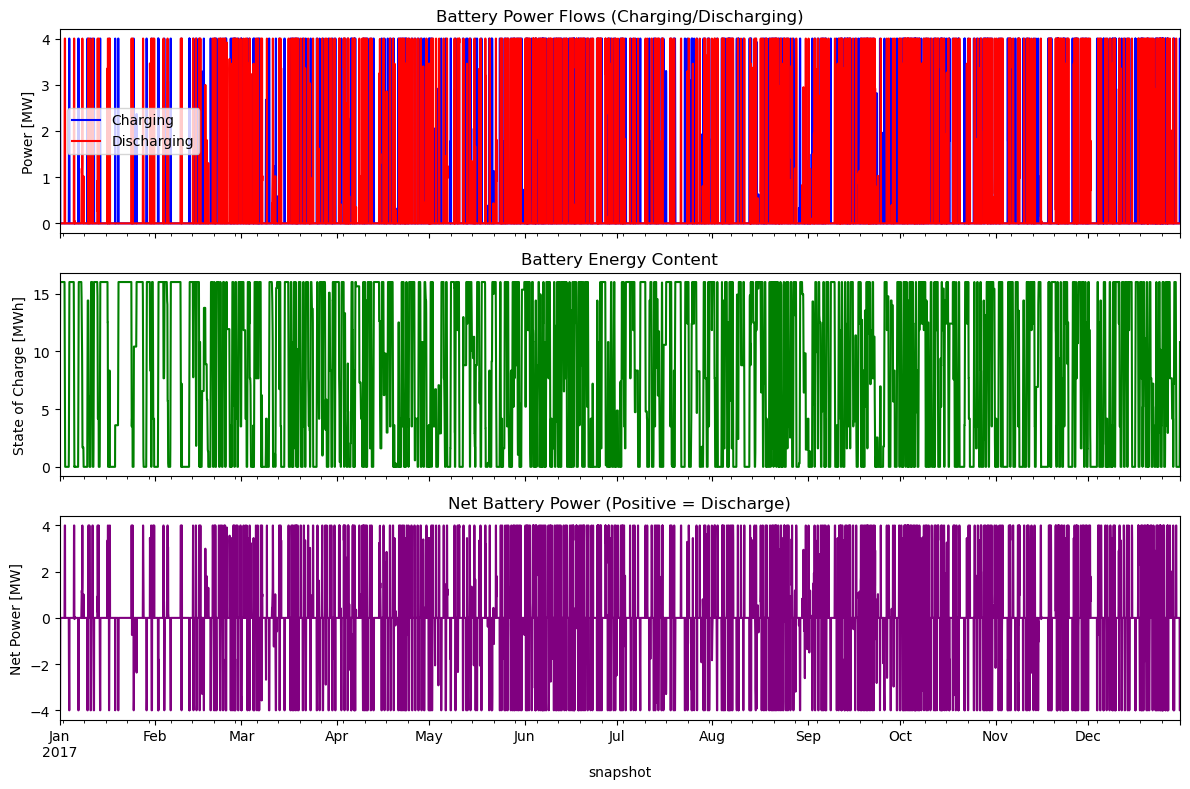

In [284]:
# Discharge power (positive when delivering electricity)
n.storage_units_t.p_dispatch["Skive_Battery"].head()

# Charging power (positive when charging)
n.storage_units_t.p_store["Skive_Battery"].head()

n.storage_units_t.state_of_charge["Skive_Battery"].head()


fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

n.storage_units_t.p_store["Skive_Battery"].plot(ax=ax[0], label="Charging", color="blue")
n.storage_units_t.p_dispatch["Skive_Battery"].plot(ax=ax[0], label="Discharging", color="red")
ax[0].set_ylabel("Power [MW]")
ax[0].legend()
ax[0].set_title("Battery Power Flows (Charging/Discharging)")

n.storage_units_t.state_of_charge["Skive_Battery"].plot(ax=ax[1], color="green")
ax[1].set_ylabel("State of Charge [MWh]")
ax[1].set_title("Battery Energy Content")

# Optional: plot net power (discharge - charge)
net_p = n.storage_units_t.p_dispatch["Skive_Battery"] - n.storage_units_t.p_store["Skive_Battery"]
net_p.plot(ax=ax[2], color="purple")
ax[2].set_ylabel("Net Power [MW]")
ax[2].set_title("Net Battery Power (Positive = Discharge)")

plt.tight_layout()
plt.show()


<Axes: xlabel='snapshot'>

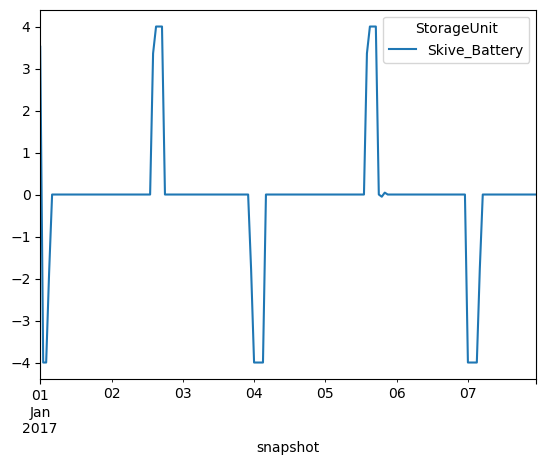

In [285]:
n.storage_units_t.p.loc["2017-01-01":"2017-01-07"].plot()

In [286]:

# align to network snapshots (fill missing with 0)
n.links_t.p0["Exports"].reindex(n.snapshots)

snapshot
2017-01-01 00:00:00    33.378257
2017-01-01 01:00:00    22.296000
2017-01-01 02:00:00     0.000000
2017-01-01 03:00:00     0.000000
2017-01-01 04:00:00     0.000000
                         ...    
2017-12-30 18:00:00     0.000000
2017-12-30 19:00:00     0.000000
2017-12-30 20:00:00     0.000000
2017-12-30 21:00:00     0.000000
2017-12-30 22:00:00     0.000000
Name: Exports, Length: 8735, dtype: float64

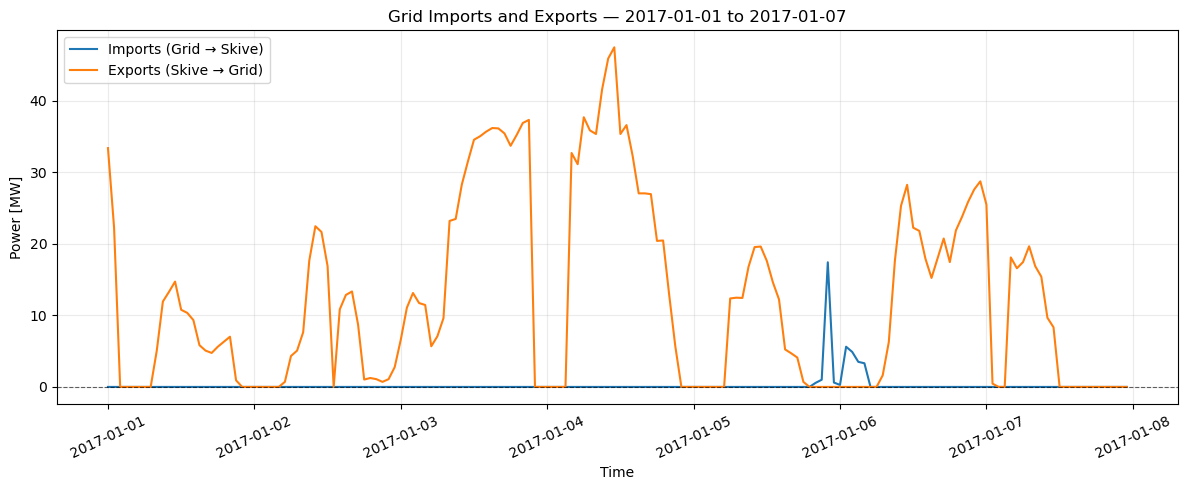

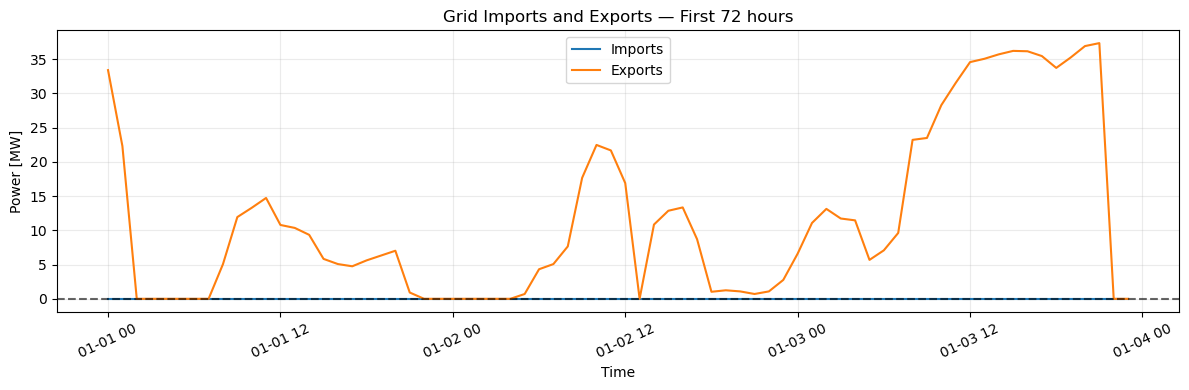

In [287]:
# ...existing code...
import matplotlib.dates as mdates

# align to network snapshots (fill missing with 0)
imports = n.links_t.p0["Imports"].reindex(n.snapshots).fillna(0)
exports = n.links_t.p0["Exports"].reindex(n.snapshots).fillna(0)

# choose timeframe
start_date = "2017-01-01"
end_date   = "2017-01-07"

# full week plot
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(imports.loc[start_date:end_date].index, imports.loc[start_date:end_date].values,
        label="Imports (Grid → Skive)", color="#1f77b4", linewidth=1.5)
ax.plot(exports.loc[start_date:end_date].index, exports.loc[start_date:end_date].values,
        label="Exports (Skive → Grid)", color="#ff7f0e", linewidth=1.5)
ax.axhline(0, color="k", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.set_title(f"Grid Imports and Exports — {start_date} to {end_date}")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=25)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# zoom: first 72 hours
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(imports.iloc[0:24*3].index, imports.iloc[0:24*3].values, label="Imports", color="#1f77b4")
ax.plot(exports.iloc[0:24*3].index, exports.iloc[0:24*3].values, label="Exports", color="#ff7f0e")
ax.axhline(0, color="k", linestyle="--", alpha=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.set_title("Grid Imports and Exports — First 72 hours")
ax.legend()
plt.xticks(rotation=25)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

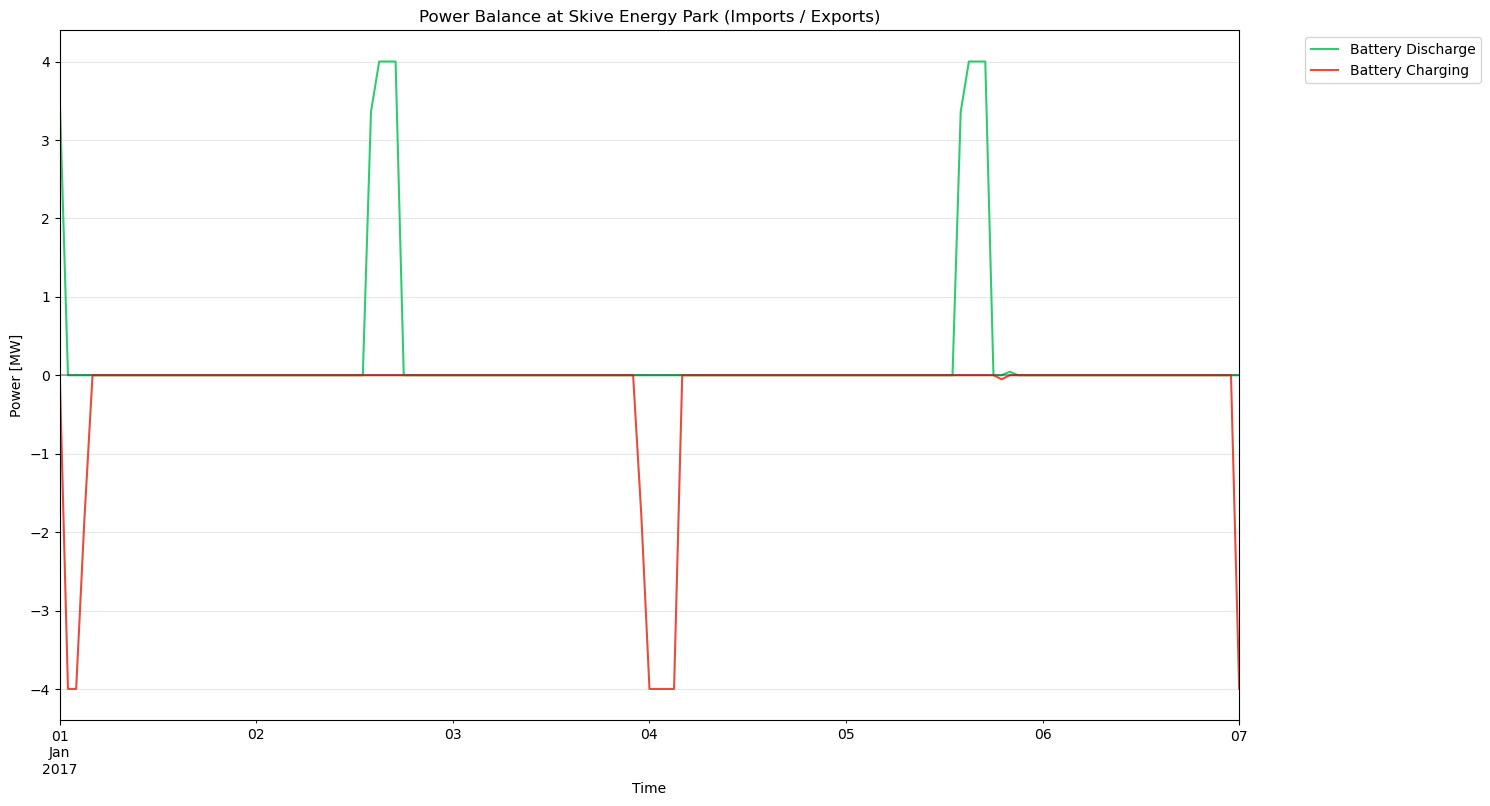

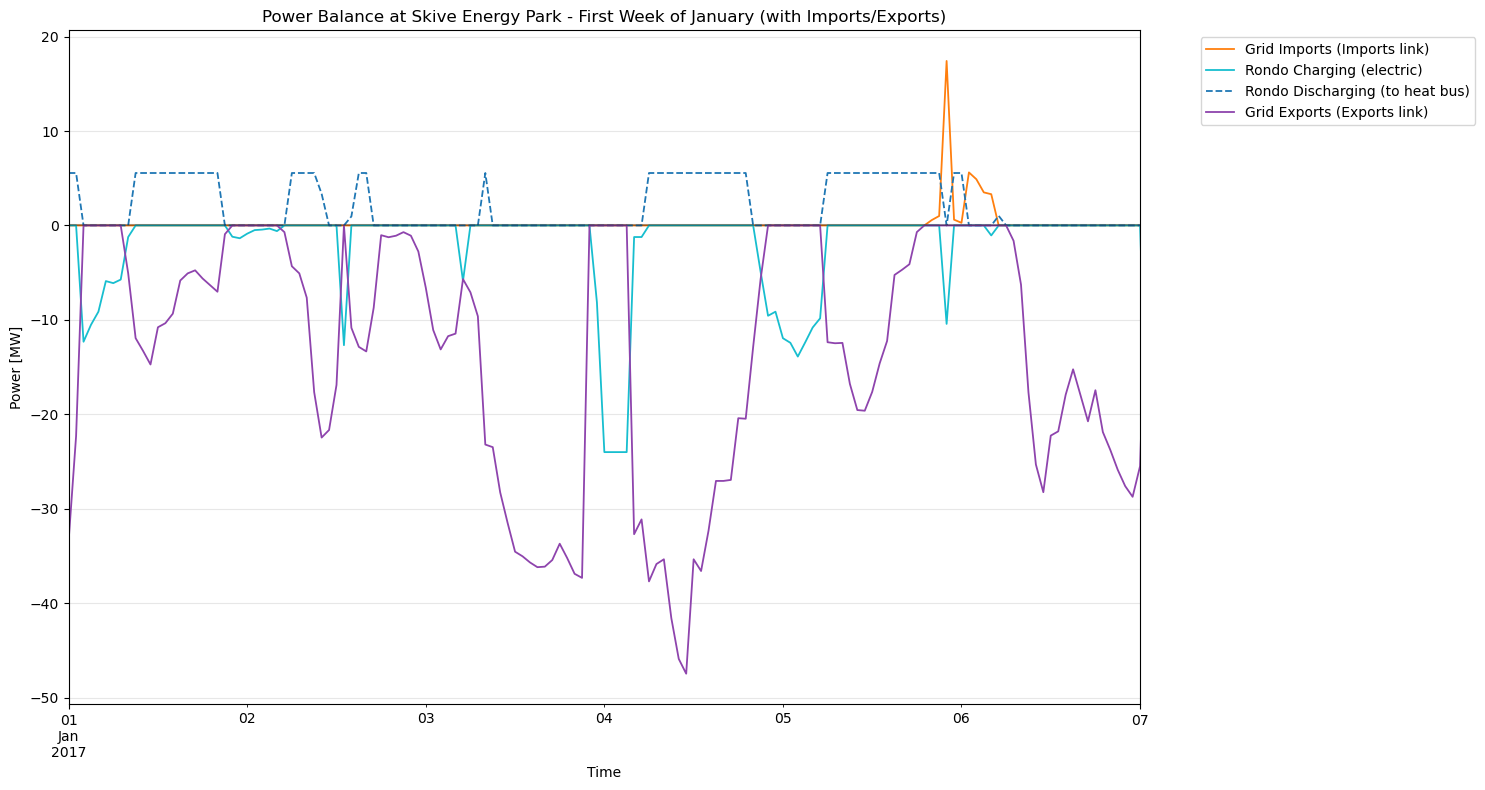

In [269]:
# ...existing code...
import matplotlib.dates as mdates

def safe_series(df, key):
    try:
        return df[key].reindex(n.snapshots).fillna(0)
    except Exception:
        return pd.Series(0.0, index=n.snapshots, name=key)

# read Imports/Exports (fall back to zero series if missing)
imports = safe_series(n.links_t.p0, "Imports")
exports = safe_series(n.links_t.p0, "Exports")

exports = -exports  # invert sign for exports to match convention

# positive import = grid -> B1, positive export = B1 -> grid
#imports_pos = imports.clip(lower=0)
#exports_pos = exports.clip(lower=0

start_date = '2017-01-01'
end_date = '2017-01-07'

# colors
col_grid_imp = '#FF7F0E'
col_grid_exp = '#8E44AD'

# Main plot
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# battery and rondo flows (existing)
n.storage_units_t.p_dispatch["Skive_Battery"].plot(ax=ax, label="Battery Discharge", color='#2ECC71', linewidth=1.5)
(-n.storage_units_t.p_store["Skive_Battery"]).plot(ax=ax, label="Battery Charging", color='#E74C3C', linewidth=1.5)

#(-n.links_t.p0.get("El_to_TES_Rondo", pd.Series(0, index=n.snapshots))).plot(ax=ax, label="Rondo Charging (electric)", color='#17BECF', linewidth=1.25)
#n.links_t.p0.get("TES_Rondo_to_Heat_Bus_Skive", pd.Series(0, index=n.snapshots)).plot(ax=ax, label="Rondo Discharging (to heat bus)", color='#1F77B4', linestyle='--', linewidth=1.25)

# plot Imports/Exports
#imports.plot(ax=ax, label="Imports (Imports link)", color=col_grid_imp, linewidth=1.3, alpha=0.9)
#exports.plot(ax=ax, label="Exports (Exports link)", color=col_grid_exp, linewidth=1.3, alpha=0.9)

ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Time')
ax.set_ylabel('Power [MW]')
ax.set_title('Power Balance at Skive Energy Park (Imports / Exports)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.xlim(start_date, end_date)
plt.show()

# Week view
plt.figure(figsize=(15, 8))

#n.generators_t.p["Skive_Solar"].loc[start_date:end_date].plot(label="Solar PV", color='#FFC300', linewidth=1.3)
#n.generators_t.p["Skive_Onshore_Wind"].loc[start_date:end_date].plot(label="Wind", color='#0057E7', linewidth=1.3)
#n.storage_units_t.p_dispatch["Skive_Battery"].loc[start_date:end_date].plot(label="Battery Discharge", color='#2ECC71', linewidth=1.3)
imports.loc[start_date:end_date].plot(label="Grid Imports (Imports link)", color=col_grid_imp, linewidth=1.3)
#(-n.links_t.p0.get("Boiler_Skive", pd.Series(0, index=n.snapshots)).loc[start_date:end_date]).plot(label="Electric Boiler", color='#7F8C8D', linewidth=1.3)
(-n.links_t.p0.get("El_to_TES_Rondo", pd.Series(0, index=n.snapshots)).loc[start_date:end_date]).plot(label="Rondo Charging (electric)", color='#17BECF', linewidth=1.3)
n.links_t.p0.get("TES_Rondo_to_Heat_Bus_Skive", pd.Series(0, index=n.snapshots)).loc[start_date:end_date].plot(label="Rondo Discharging (to heat bus)", color='#1F77B4', linestyle='--', linewidth=1.3)
#(-n.storage_units_t.p_store["Skive_Battery"].loc[start_date:end_date]).plot(label="Battery Charging", color='#E74C3C', linewidth=1.3)
exports.loc[start_date:end_date].plot(label="Grid Exports (Exports link)", color=col_grid_exp, linewidth=1.3)

plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.xlabel('Time')
plt.ylabel('Power [MW]')
plt.title('Power Balance at Skive Energy Park - First Week of January (with Imports/Exports)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(start_date, end_date)
plt.tight_layout()
plt.show()

In [253]:
"Optimal Generator Capacity (GW)";
n.generators.p_nom_opt # in GW

Generator
Skive_Solar           36.000000
Skive_Onshore_Wind    54.000000
Grid_Generator        36.655212
Name: p_nom_opt, dtype: float64

In [254]:
"Minimum cost of the system";
n.objective/1e9 # Bn of EUR annum

-0.0023267582783705423

In [255]:
n.stores.e_nom_opt

Store
Rondo_Concrete_Heat_Storage      100.000000
Grid_Store                     89447.532664
Name: e_nom_opt, dtype: float64